# Master PCA — Loading interpretation dashboard

Per-component report cards for the master PCA artifact. For each principal component we show:

1. The variance it explains.
2. The named features (numeric + binary blocks) most correlated with the axis, split into positive and negative directions.
3. The block mix (numeric / binary / embeddings) — how much of the component's norm comes from each block.
4. A heuristic semantic title and a short interpretation summary, derived from the loading pattern.

This is a latent-factor report — it is *not* a SHAP explanation. Loadings come straight from `pca.components_` on the standardized + block-weighted feature matrix, so they are comparable across blocks despite the 9/11/256 dimensionality split.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not find project root containing src/ and requirements.txt.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR

FEATURES_DIR = PROJECT_ROOT / "data" / "features"
VIZ_CACHE = FEATURES_DIR / "viz_cache"
VIZ_CACHE.mkdir(parents=True, exist_ok=True)

TOP_K_COMPONENTS = 20
TOP_K_FEATURES_PER_SIDE = 5

BLOCK_PALETTE = {
    "numeric": "#4e79a7",
    "binary": "#f28e2b",
    "embeddings": "#59a14f",
}
POS_COLOR = "#2e7d32"
NEG_COLOR = "#c62828"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Will interpret first {TOP_K_COMPONENTS} components.")

Project root: /home/nakato/projects/BigBook
Will interpret first 20 components.


## Load PCA artifacts

In [2]:
PCA_MODEL_PATH = FEATURES_DIR / "master_pca_model.joblib"
PCA_META_PATH = FEATURES_DIR / "master_pca_meta.json"

missing = [path for path in [PCA_MODEL_PATH, PCA_META_PATH] if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing PCA artifacts. Run `env/bin/python -m src.reduction.build_master_feature_matrix` first.\n"
        + "\n".join(str(path) for path in missing)
    )

pca_artifact = joblib.load(PCA_MODEL_PATH)
meta = json.loads(PCA_META_PATH.read_text(encoding="utf-8"))

pca = pca_artifact["pca"]
components = pca.components_  # shape: (n_components, n_features)
explained_ratio = pca.explained_variance_ratio_
block_slices = pca_artifact["block_slices"]
block_columns = pca_artifact["block_columns"]

n_components = components.shape[0]
TOP_K_COMPONENTS = min(TOP_K_COMPONENTS, n_components)

print(f"PCA components: {n_components}")
print(f"Feature dimensions: {components.shape[1]}")
print(f"Block slices: {block_slices}")
print(f"Variance covered by first {TOP_K_COMPONENTS} PCs: {explained_ratio[:TOP_K_COMPONENTS].sum():.3%}")

PCA components: 173
Feature dimensions: 276
Block slices: {'numeric': (0, 9), 'binary': (9, 20), 'embeddings': (20, 276)}
Variance covered by first 20 PCs: 69.580%


## Friendly feature labels

Mapping from raw feature names to human-readable labels for the report cards. Only the named blocks (numeric + binary) are labeled — the 256-dim embedding block is interpreted as an aggregate, since individual `emb_*` dimensions are not human-interpretable.

In [3]:
FEATURE_FRIENDLY = {
    # numeric block
    "average_rating": "Avg rating",
    "log_ratings_count": "Rating volume (log)",
    "log_text_reviews_count": "Review activity (log)",
    "num_pages": "Page count",
    "num_pages_missing": "Page count missing",
    "publication_year": "Publication year",
    "publication_year_missing": "Year missing",
    "author_count": "Co-authorship",
    "genre_count": "Genre breadth",
    # binary block
    "series": "Part of a series",
    "genre_fantasy": "Genre: Fantasy",
    "genre_mystery": "Genre: Mystery / Crime",
    "genre_history": "Genre: History / Biography",
    "genre_ya": "Genre: Young Adult",
    "genre_romance": "Genre: Romance",
    "language_code_eng": "Lang: eng (generic)",
    "language_code_en_us": "Lang: en-US",
    "language_code_en_gb": "Lang: en-GB",
    "language_code_en_ca": "Lang: en-CA",
    "language_code_other": "Lang: other",
}

def friendly(feature: str) -> str:
    return FEATURE_FRIENDLY.get(feature, feature)

named_features = [
    *block_columns["numeric"],
    *block_columns["binary"],
]
missing_labels = [feat for feat in named_features if feat not in FEATURE_FRIENDLY]
if missing_labels:
    print(f"Note: {len(missing_labels)} named features have no friendly label and will use their raw name:")
    for feat in missing_labels:
        print(f"  - {feat}")
else:
    print(f"All {len(named_features)} named features have friendly labels.")

All 20 named features have friendly labels.


## Helper functions

- `component_block_shares(idx)` returns the fraction of the component's L2 norm that comes from each block. This is the natural cross-block comparison metric because the feature matrix is block-weighted by `1/sqrt(block_dim)`, so a single embedding dim and a single binary flag carry comparable scale.
- `named_loadings(idx)` returns a DataFrame of (feature, block, loading) for the numeric + binary blocks — the parts that have human-readable names.

In [4]:
def component_block_shares(component_idx: int) -> dict[str, float]:
    component = components[component_idx]
    norms = {
        name: float(np.linalg.norm(component[start:end]))
        for name, (start, end) in block_slices.items()
    }
    total = sum(norms.values())
    if total == 0:
        return {name: 0.0 for name in norms}
    return {name: norm / total for name, norm in norms.items()}

def named_loadings(component_idx: int) -> pd.DataFrame:
    component = components[component_idx]
    rows = []
    for block_name in ("numeric", "binary"):
        start, end = block_slices[block_name]
        for column, loading in zip(block_columns[block_name], component[start:end]):
            rows.append({
                "feature": column,
                "label": friendly(column),
                "block": block_name,
                "loading": float(loading),
            })
    df = pd.DataFrame(rows)
    df["abs_loading"] = df["loading"].abs()
    return df.sort_values("loading", ascending=False).reset_index(drop=True)

def top_signed_features(loadings: pd.DataFrame, k: int = TOP_K_FEATURES_PER_SIDE) -> pd.DataFrame:
    """Top-k positive and bottom-k negative loadings, concatenated and sorted ascending for plotting."""
    positives = loadings[loadings["loading"] > 0].nlargest(k, "loading")
    negatives = loadings[loadings["loading"] < 0].nsmallest(k, "loading")
    return pd.concat([negatives, positives], ignore_index=True).sort_values("loading")

## Heuristic semantic interpretation

Each axis gets:

- **Title**: a short "positive ↔ negative" label built from the dominant labeled features. If the embedding block contributes more than half of the component's norm we mark the axis as *(semantic theme)* — the description-embedding signal is real but its individual dimensions aren't human-readable.
- **Summary**: the variance share, the block mix, and which named features sit at each end of the axis.

Pattern detectors (`engagement`, `genre`, `recency`, etc.) only fire when the relevant features are clearly dominant. When no pattern fits we fall back to a generic "top positive vs. top negative" sentence.

In [5]:
POPULARITY_FEATURES = {"log_ratings_count", "log_text_reviews_count", "average_rating"}
GENRE_FEATURES = {"genre_fantasy", "genre_mystery", "genre_history", "genre_ya", "genre_romance"}
LANGUAGE_FEATURES = {feat for feat in FEATURE_FRIENDLY if feat.startswith("language_code_")}
MISSINGNESS_FEATURES = {"num_pages_missing", "publication_year_missing"}
RECENCY_FEATURES = {"publication_year"}

EMBEDDING_DOMINANCE_THRESHOLD = 0.5
PATTERN_DOMINANCE_THRESHOLD = 0.6  # fraction of top-2 |loadings| inside a feature group

def _group_share(top_features: pd.DataFrame, group: set[str]) -> float:
    """Share of top features (by abs loading) that fall in `group`."""
    if top_features.empty:
        return 0.0
    in_group = top_features["feature"].isin(group)
    weight_in = top_features.loc[in_group, "abs_loading"].sum()
    weight_total = top_features["abs_loading"].sum()
    return float(weight_in / weight_total) if weight_total else 0.0

def semantic_title(component_idx: int) -> str:
    loadings = named_loadings(component_idx)
    if loadings.empty:
        return f"PC{component_idx}"
    top_pos = loadings[loadings["loading"] > 0].head(1)
    top_neg = loadings[loadings["loading"] < 0].tail(1)
    pos_label = top_pos.iloc[0]["label"] if not top_pos.empty else "—"
    neg_label = top_neg.iloc[0]["label"] if not top_neg.empty else "—"
    title = f"{pos_label} ↔ {neg_label}"
    shares = component_block_shares(component_idx)
    if shares.get("embeddings", 0.0) > EMBEDDING_DOMINANCE_THRESHOLD:
        title += " (semantic theme)"
    return title

def axis_pattern(component_idx: int) -> str:
    loadings = named_loadings(component_idx)
    if loadings.empty:
        return "unstructured"
    top4 = loadings.nlargest(4, "abs_loading")
    if _group_share(top4, POPULARITY_FEATURES) >= PATTERN_DOMINANCE_THRESHOLD:
        return "engagement / popularity axis"
    if _group_share(top4, GENRE_FEATURES) >= PATTERN_DOMINANCE_THRESHOLD:
        return "genre-separation axis"
    if _group_share(top4, LANGUAGE_FEATURES) >= PATTERN_DOMINANCE_THRESHOLD:
        return "language-edition axis"
    if _group_share(top4, MISSINGNESS_FEATURES) >= PATTERN_DOMINANCE_THRESHOLD:
        return "metadata-completeness axis"
    if _group_share(top4, RECENCY_FEATURES | {"num_pages"}) >= PATTERN_DOMINANCE_THRESHOLD:
        return "format / recency axis"
    return "mixed-signal axis"

def interpretation_summary(component_idx: int) -> str:
    loadings = named_loadings(component_idx)
    shares = component_block_shares(component_idx)
    variance = explained_ratio[component_idx]
    pattern = axis_pattern(component_idx)
    pos = loadings[loadings["loading"] > 0].head(3)["label"].tolist()
    neg = loadings[loadings["loading"] < 0].tail(3).iloc[::-1]["label"].tolist()

    block_mix = ", ".join(
        f"{name} {shares.get(name, 0.0):.0%}"
        for name in ("numeric", "binary", "embeddings")
    )
    parts = [
        f"Explains **{variance:.2%}** of the total variance.",
        f"Block mix: {block_mix}. Reads as a {pattern}.",
    ]
    if shares.get("embeddings", 0.0) > EMBEDDING_DOMINANCE_THRESHOLD:
        parts.append(
            "More than half of the axis norm comes from the description-embedding block, so the axis encodes a "
            "semantic theme that is not directly named by any single feature."
        )
    if pos:
        parts.append("Positive end → " + ", ".join(pos) + ".")
    if neg:
        parts.append("Negative end → " + ", ".join(neg) + ".")
    return " ".join(parts)

# Quick smoke check
for idx in range(min(3, n_components)):
    print(f"PC{idx}: {semantic_title(idx)}")
    print(f"  {interpretation_summary(idx)}\n")

PC0: Review activity (log) ↔ Page count missing
  Explains **7.94%** of the total variance. Block mix: numeric 61%, binary 28%, embeddings 11%. Reads as a engagement / popularity axis. Positive end → Review activity (log), Rating volume (log), Genre: Young Adult. Negative end → Page count missing, Genre: Mystery / Crime, Year missing.

PC1: Genre: Romance ↔ Genre: History / Biography
  Explains **7.10%** of the total variance. Block mix: numeric 47%, binary 36%, embeddings 17%. Reads as a mixed-signal axis. Positive end → Genre: Romance, Page count missing, Publication year. Negative end → Genre: History / Biography, Page count, Genre: Mystery / Crime.

PC2: Year missing ↔ Lang: eng (generic)
  Explains **6.80%** of the total variance. Block mix: numeric 53%, binary 42%, embeddings 5%. Reads as a mixed-signal axis. Positive end → Year missing, Page count missing, Lang: en-US. Negative end → Lang: eng (generic), Genre breadth, Genre: Young Adult.



## Report card visualization

One figure per principal component. Two panels:

- **Left**: top positive (green) and top negative (red) named feature loadings, sorted ascending.
- **Right**: block mix bar — share of the component's L2 norm coming from each block.

The figure title carries the semantic axis name and variance share. The interpretation summary is printed below the figure as a caption.

In [6]:
from IPython.display import Markdown, display

def plot_report_card(component_idx: int) -> plt.Figure:
    loadings = named_loadings(component_idx)
    top = top_signed_features(loadings, k=TOP_K_FEATURES_PER_SIDE)
    shares = component_block_shares(component_idx)
    variance = explained_ratio[component_idx]
    title = semantic_title(component_idx)

    fig, (ax_loadings, ax_blocks) = plt.subplots(
        1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [3.2, 1.0]}
    )

    bar_colors = [POS_COLOR if value >= 0 else NEG_COLOR for value in top["loading"]]
    ax_loadings.barh(top["label"], top["loading"], color=bar_colors, edgecolor="white")
    ax_loadings.axvline(0, color="black", linewidth=0.8)
    ax_loadings.set_xlabel("Loading on PC%d" % component_idx)
    ax_loadings.set_title(
        f"PC{component_idx} — {title}\n{variance:.2%} variance",
        loc="left",
        fontsize=12,
        fontweight="bold",
    )
    max_abs = float(np.abs(top["loading"]).max()) if not top.empty else 0.1
    pad = max_abs * 0.18 if max_abs else 0.05
    ax_loadings.set_xlim(-(max_abs + pad), max_abs + pad)
    for value, label in zip(top["loading"], top["label"]):
        offset = pad * 0.25 if value >= 0 else -pad * 0.25
        ax_loadings.text(
            value + offset,
            label,
            f"{value:+.3f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=9,
            color="#333333",
        )

    block_order = ["numeric", "binary", "embeddings"]
    block_values = [shares.get(name, 0.0) for name in block_order]
    bottom = 0.0
    for name, value in zip(block_order, block_values):
        ax_blocks.bar(
            ["block mix"],
            [value],
            bottom=bottom,
            color=BLOCK_PALETTE[name],
            edgecolor="white",
            label=f"{name} ({value:.0%})",
        )
        if value > 0.04:
            ax_blocks.text(
                0,
                bottom + value / 2,
                f"{name}\n{value:.0%}",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )
        bottom += value
    ax_blocks.set_ylim(0, 1)
    ax_blocks.set_ylabel("Share of component norm")
    ax_blocks.set_title("Block mix", fontsize=11)
    ax_blocks.set_xticks([])
    ax_blocks.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=False)

    plt.tight_layout()
    return fig

def render_component(component_idx: int) -> None:
    fig = plot_report_card(component_idx)
    plt.show()
    plt.close(fig)
    display(Markdown(f"_{interpretation_summary(component_idx)}_\n\n---"))

## Report cards — first 20 PCs

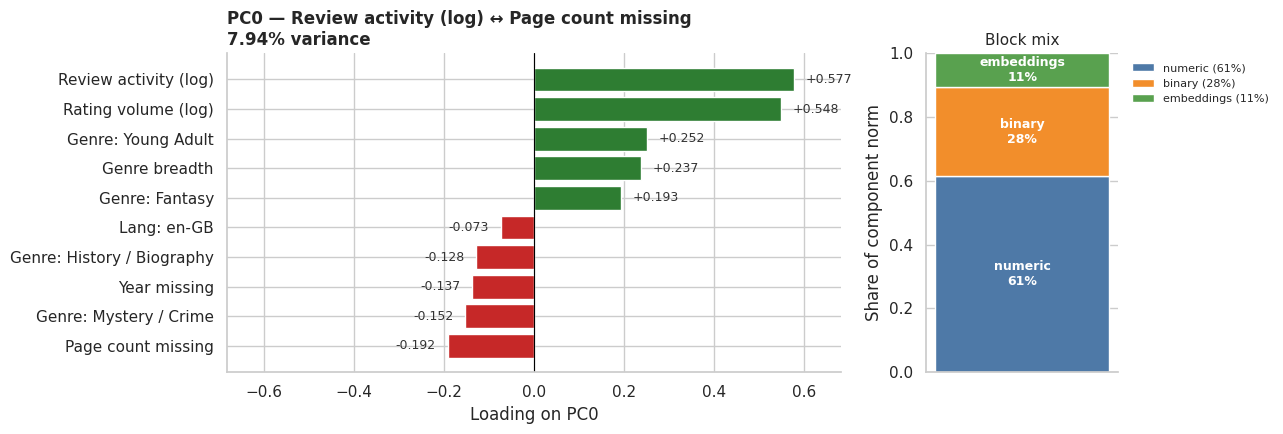

_Explains **7.94%** of the total variance. Block mix: numeric 61%, binary 28%, embeddings 11%. Reads as a engagement / popularity axis. Positive end → Review activity (log), Rating volume (log), Genre: Young Adult. Negative end → Page count missing, Genre: Mystery / Crime, Year missing._

---

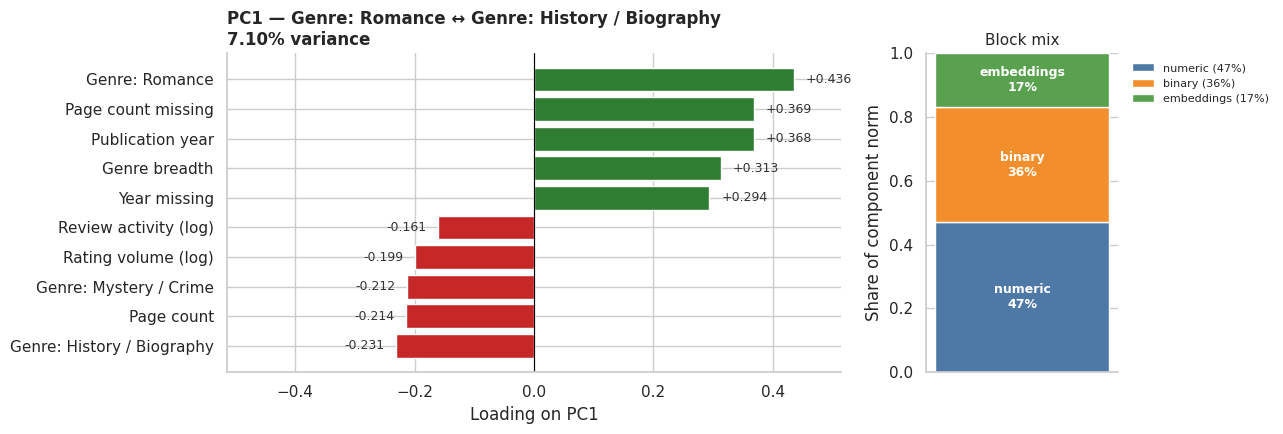

_Explains **7.10%** of the total variance. Block mix: numeric 47%, binary 36%, embeddings 17%. Reads as a mixed-signal axis. Positive end → Genre: Romance, Page count missing, Publication year. Negative end → Genre: History / Biography, Page count, Genre: Mystery / Crime._

---

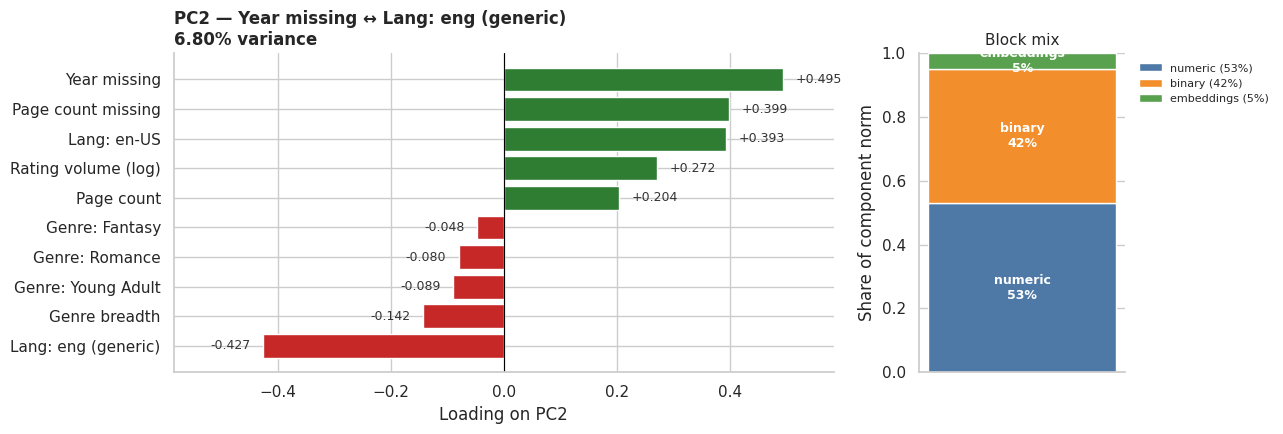

_Explains **6.80%** of the total variance. Block mix: numeric 53%, binary 42%, embeddings 5%. Reads as a mixed-signal axis. Positive end → Year missing, Page count missing, Lang: en-US. Negative end → Lang: eng (generic), Genre breadth, Genre: Young Adult._

---

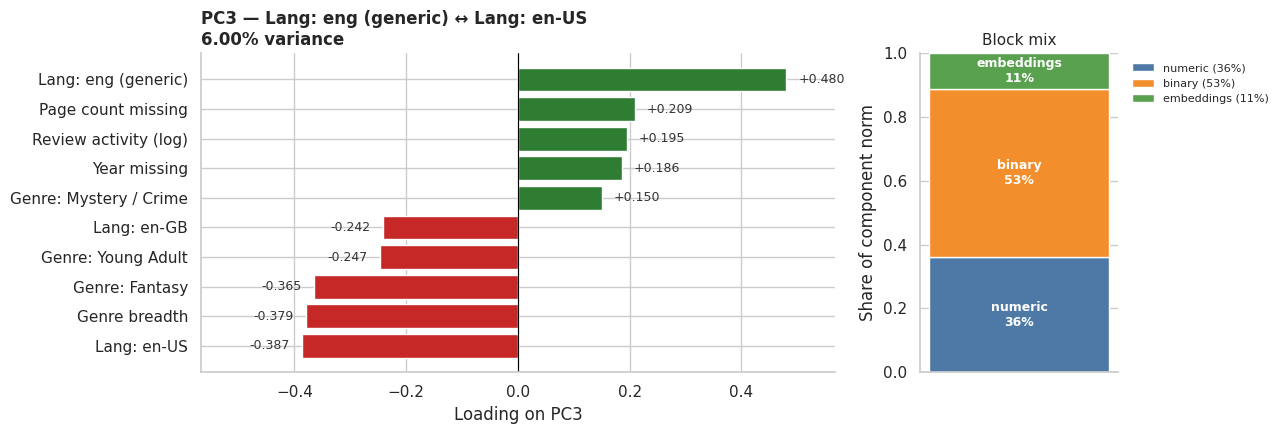

_Explains **6.00%** of the total variance. Block mix: numeric 36%, binary 53%, embeddings 11%. Reads as a mixed-signal axis. Positive end → Lang: eng (generic), Page count missing, Review activity (log). Negative end → Lang: en-US, Genre breadth, Genre: Fantasy._

---

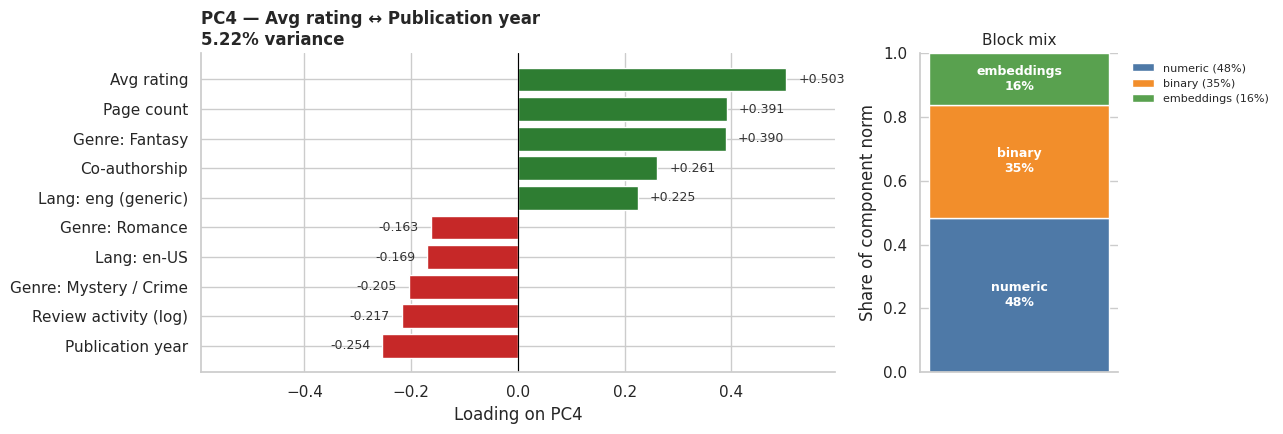

_Explains **5.22%** of the total variance. Block mix: numeric 48%, binary 35%, embeddings 16%. Reads as a mixed-signal axis. Positive end → Avg rating, Page count, Genre: Fantasy. Negative end → Publication year, Review activity (log), Genre: Mystery / Crime._

---

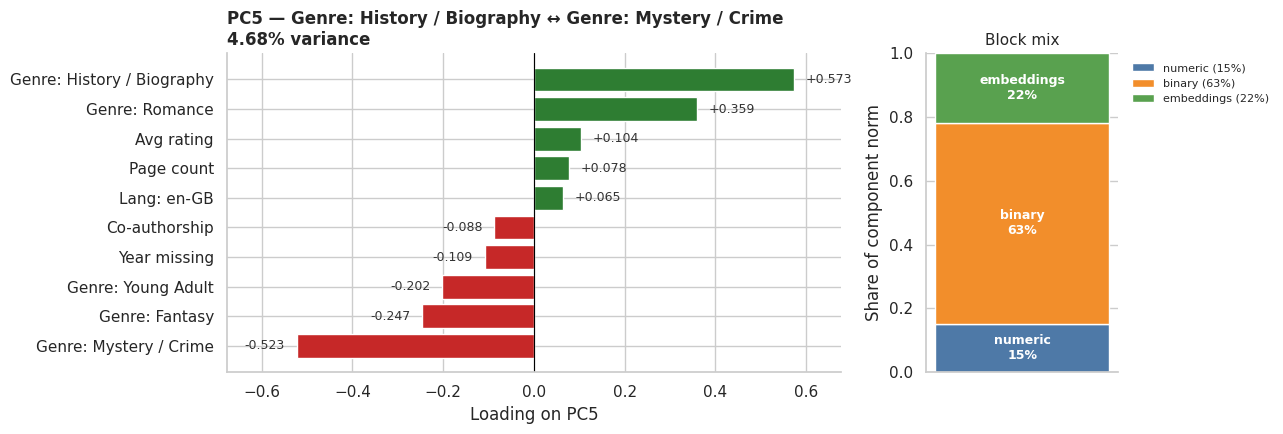

_Explains **4.68%** of the total variance. Block mix: numeric 15%, binary 63%, embeddings 22%. Reads as a genre-separation axis. Positive end → Genre: History / Biography, Genre: Romance, Avg rating. Negative end → Genre: Mystery / Crime, Genre: Fantasy, Genre: Young Adult._

---

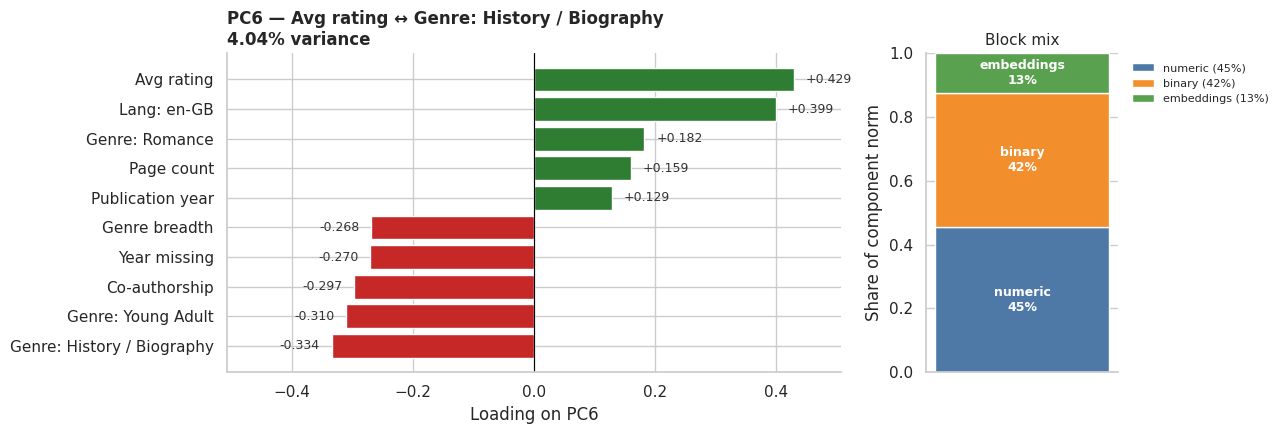

_Explains **4.04%** of the total variance. Block mix: numeric 45%, binary 42%, embeddings 13%. Reads as a mixed-signal axis. Positive end → Avg rating, Lang: en-GB, Genre: Romance. Negative end → Genre: History / Biography, Genre: Young Adult, Co-authorship._

---

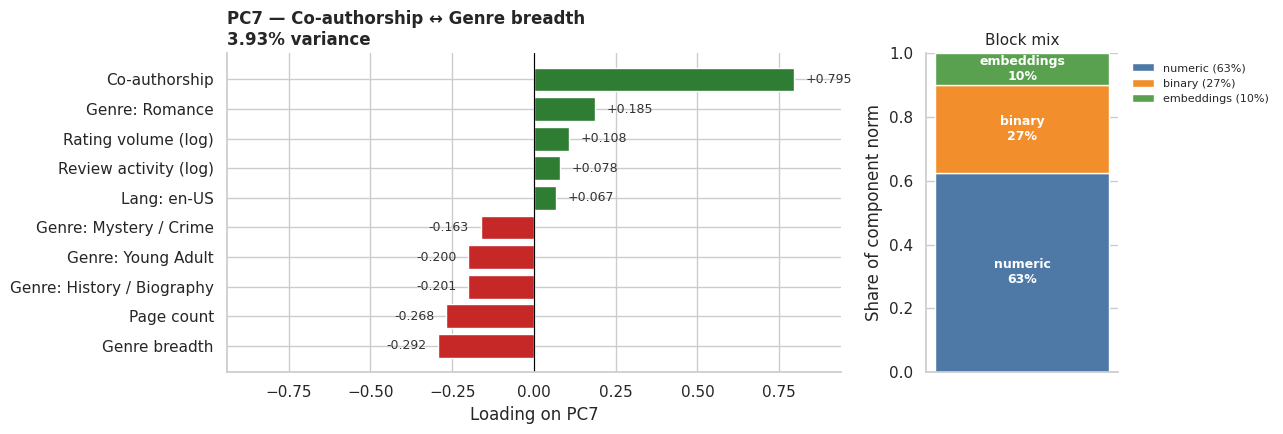

_Explains **3.93%** of the total variance. Block mix: numeric 63%, binary 27%, embeddings 10%. Reads as a mixed-signal axis. Positive end → Co-authorship, Genre: Romance, Rating volume (log). Negative end → Genre breadth, Page count, Genre: History / Biography._

---

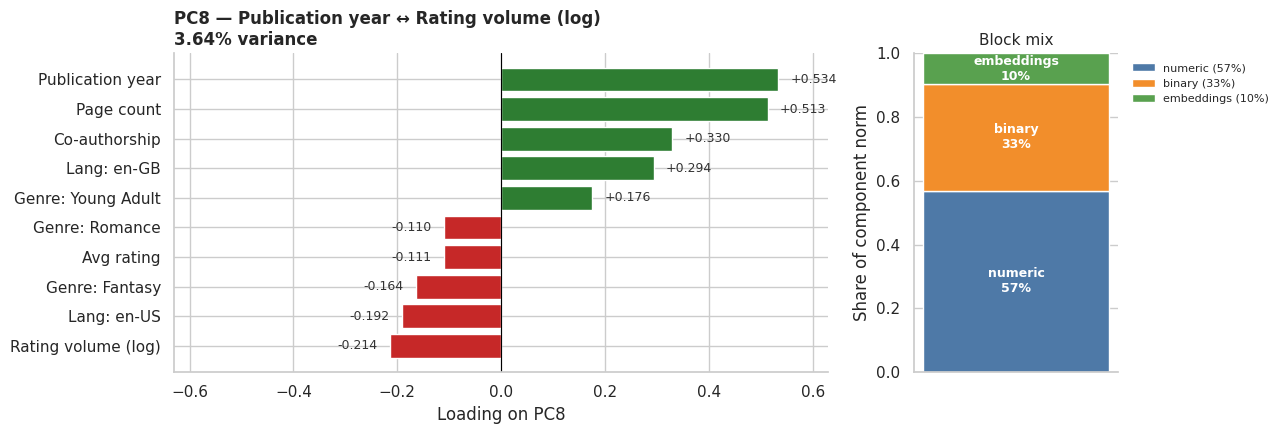

_Explains **3.64%** of the total variance. Block mix: numeric 57%, binary 33%, embeddings 10%. Reads as a format / recency axis. Positive end → Publication year, Page count, Co-authorship. Negative end → Rating volume (log), Lang: en-US, Genre: Fantasy._

---

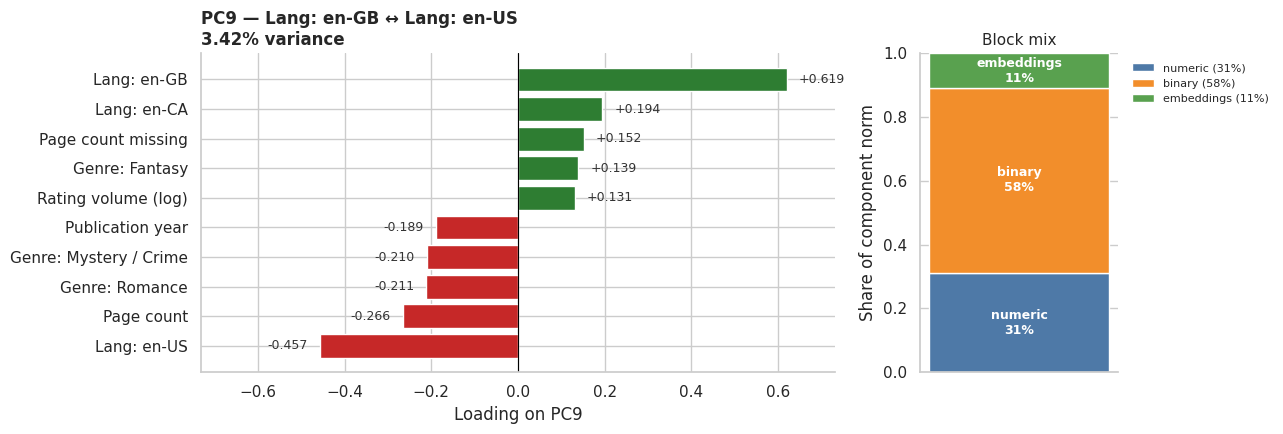

_Explains **3.42%** of the total variance. Block mix: numeric 31%, binary 58%, embeddings 11%. Reads as a language-edition axis. Positive end → Lang: en-GB, Lang: en-CA, Page count missing. Negative end → Lang: en-US, Page count, Genre: Romance._

---

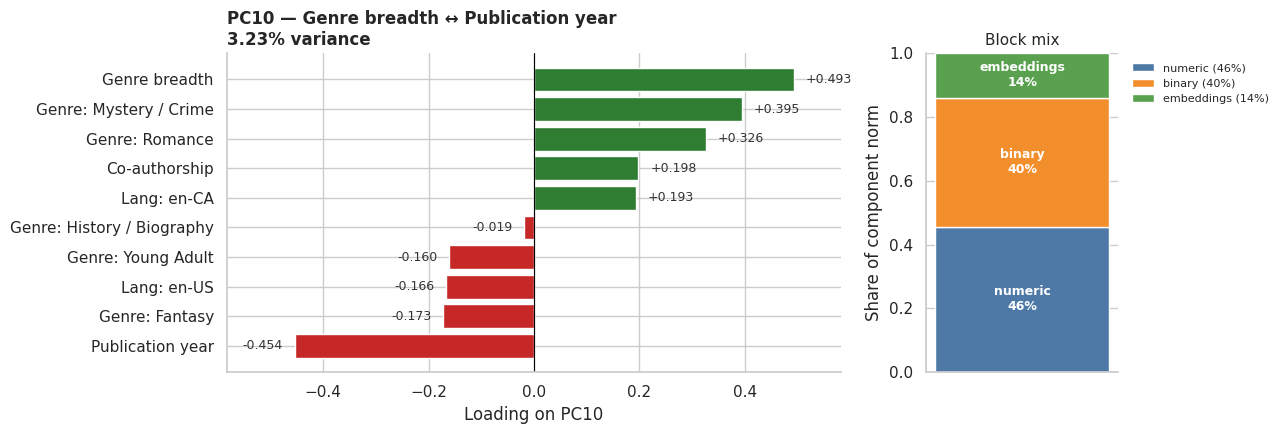

_Explains **3.23%** of the total variance. Block mix: numeric 46%, binary 40%, embeddings 14%. Reads as a mixed-signal axis. Positive end → Genre breadth, Genre: Mystery / Crime, Genre: Romance. Negative end → Publication year, Genre: Fantasy, Lang: en-US._

---

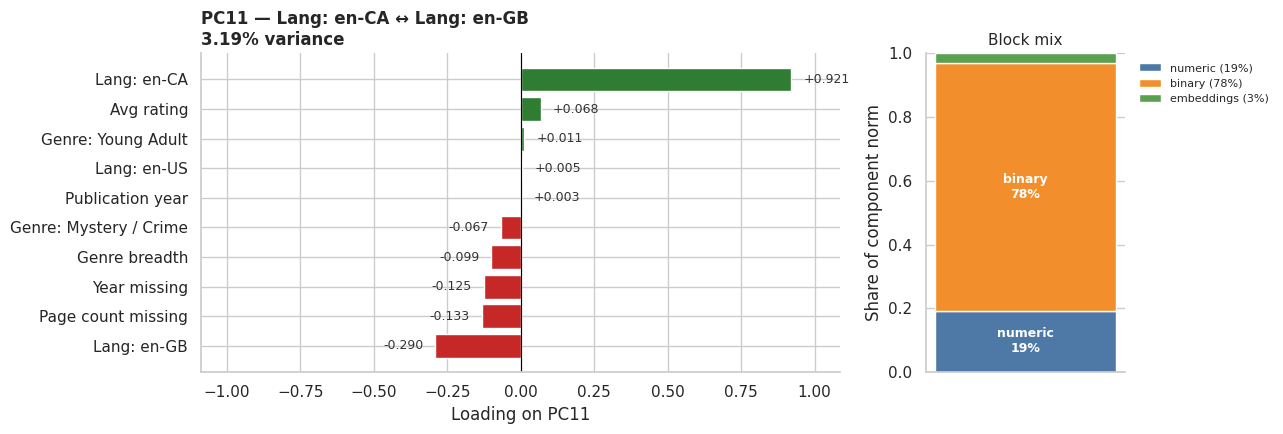

_Explains **3.19%** of the total variance. Block mix: numeric 19%, binary 78%, embeddings 3%. Reads as a language-edition axis. Positive end → Lang: en-CA, Avg rating, Genre: Young Adult. Negative end → Lang: en-GB, Page count missing, Year missing._

---

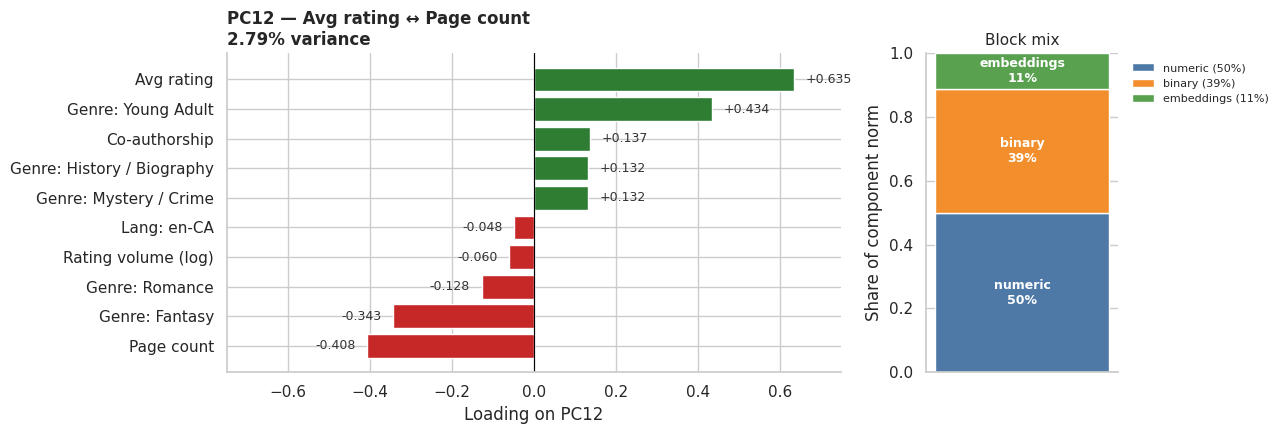

_Explains **2.79%** of the total variance. Block mix: numeric 50%, binary 39%, embeddings 11%. Reads as a mixed-signal axis. Positive end → Avg rating, Genre: Young Adult, Co-authorship. Negative end → Page count, Genre: Fantasy, Genre: Romance._

---

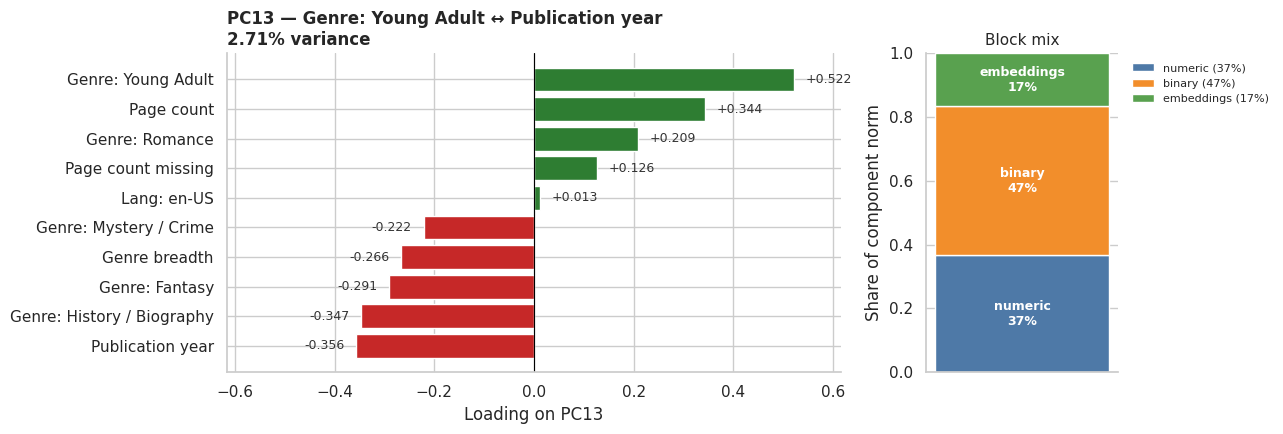

_Explains **2.71%** of the total variance. Block mix: numeric 37%, binary 47%, embeddings 17%. Reads as a mixed-signal axis. Positive end → Genre: Young Adult, Page count, Genre: Romance. Negative end → Publication year, Genre: History / Biography, Genre: Fantasy._

---

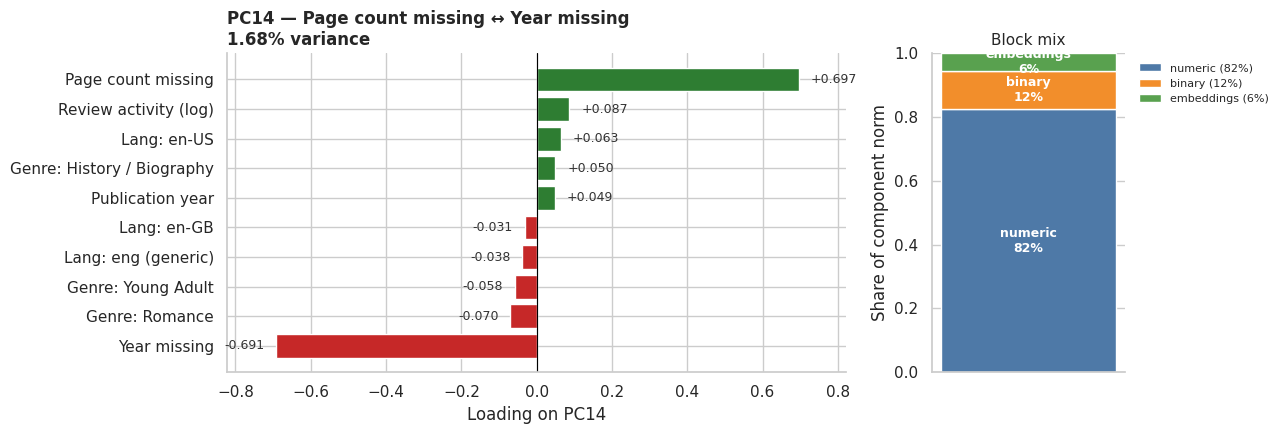

_Explains **1.68%** of the total variance. Block mix: numeric 82%, binary 12%, embeddings 6%. Reads as a metadata-completeness axis. Positive end → Page count missing, Review activity (log), Lang: en-US. Negative end → Year missing, Genre: Romance, Genre: Young Adult._

---

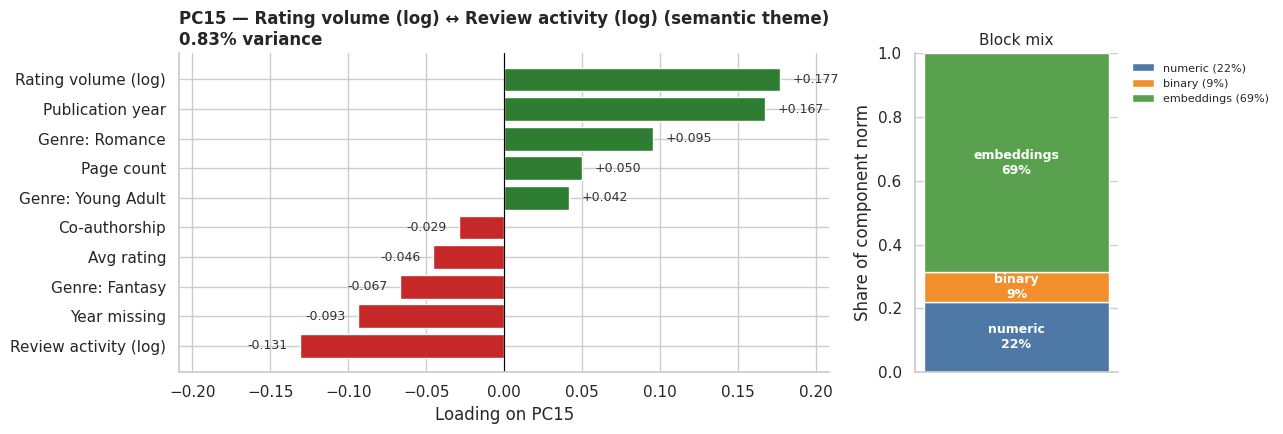

_Explains **0.83%** of the total variance. Block mix: numeric 22%, binary 9%, embeddings 69%. Reads as a mixed-signal axis. More than half of the axis norm comes from the description-embedding block, so the axis encodes a semantic theme that is not directly named by any single feature. Positive end → Rating volume (log), Publication year, Genre: Romance. Negative end → Review activity (log), Year missing, Genre: Fantasy._

---

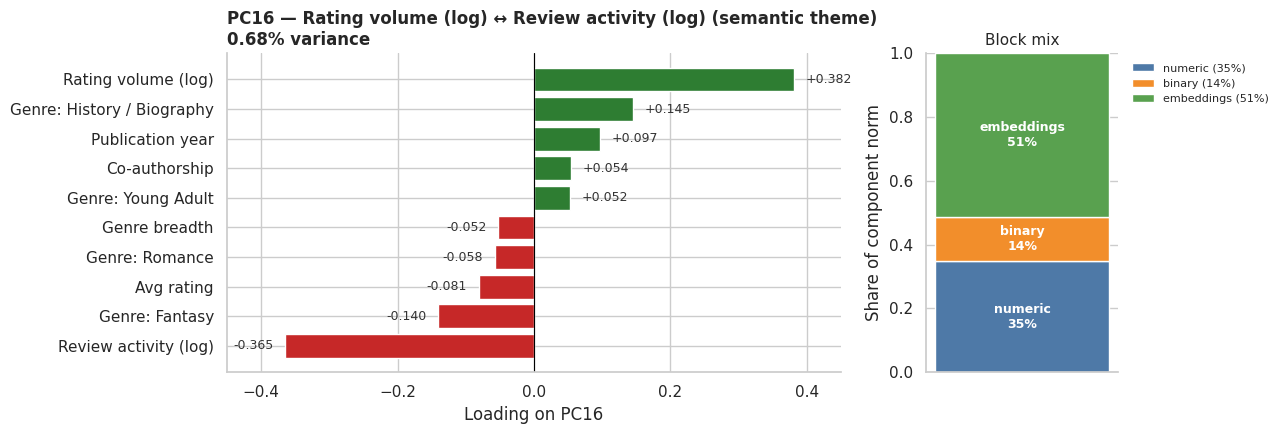

_Explains **0.68%** of the total variance. Block mix: numeric 35%, binary 14%, embeddings 51%. Reads as a engagement / popularity axis. More than half of the axis norm comes from the description-embedding block, so the axis encodes a semantic theme that is not directly named by any single feature. Positive end → Rating volume (log), Genre: History / Biography, Publication year. Negative end → Review activity (log), Genre: Fantasy, Avg rating._

---

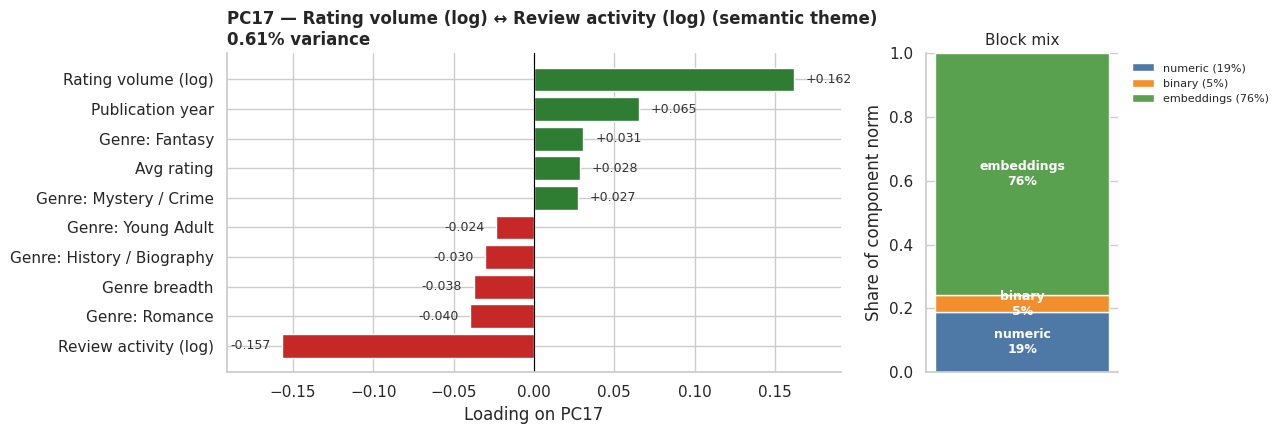

_Explains **0.61%** of the total variance. Block mix: numeric 19%, binary 5%, embeddings 76%. Reads as a engagement / popularity axis. More than half of the axis norm comes from the description-embedding block, so the axis encodes a semantic theme that is not directly named by any single feature. Positive end → Rating volume (log), Publication year, Genre: Fantasy. Negative end → Review activity (log), Genre: Romance, Genre breadth._

---

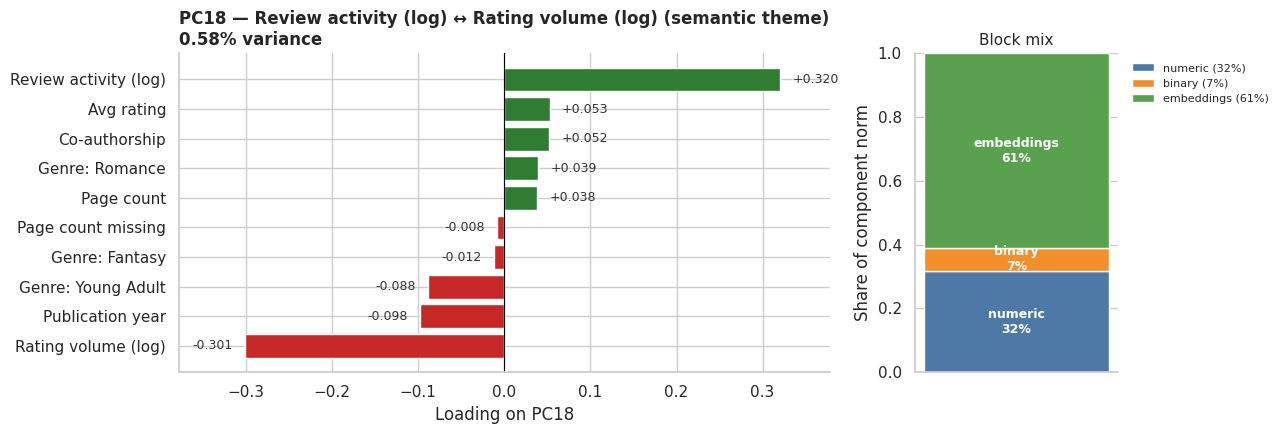

_Explains **0.58%** of the total variance. Block mix: numeric 32%, binary 7%, embeddings 61%. Reads as a engagement / popularity axis. More than half of the axis norm comes from the description-embedding block, so the axis encodes a semantic theme that is not directly named by any single feature. Positive end → Review activity (log), Avg rating, Co-authorship. Negative end → Rating volume (log), Publication year, Genre: Young Adult._

---

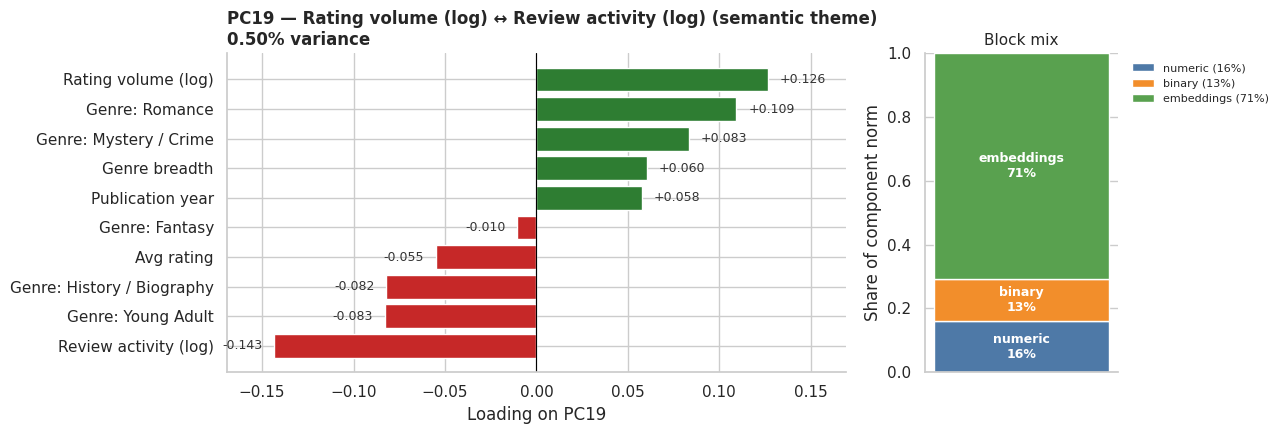

_Explains **0.50%** of the total variance. Block mix: numeric 16%, binary 13%, embeddings 71%. Reads as a mixed-signal axis. More than half of the axis norm comes from the description-embedding block, so the axis encodes a semantic theme that is not directly named by any single feature. Positive end → Rating volume (log), Genre: Romance, Genre: Mystery / Crime. Negative end → Review activity (log), Genre: Young Adult, Genre: History / Biography._

---

In [7]:
for component_idx in range(TOP_K_COMPONENTS):
    render_component(component_idx)

## Summary table

One row per interpreted component. Useful as a quick reference when reading the report cards above.

In [8]:
summary_rows = []
for component_idx in range(TOP_K_COMPONENTS):
    loadings = named_loadings(component_idx)
    shares = component_block_shares(component_idx)
    pos = loadings[loadings["loading"] > 0].head(3)["label"].tolist()
    neg = loadings[loadings["loading"] < 0].tail(3).iloc[::-1]["label"].tolist()
    summary_rows.append({
        "PC": component_idx,
        "variance": explained_ratio[component_idx],
        "cumulative": float(explained_ratio[: component_idx + 1].sum()),
        "axis": semantic_title(component_idx),
        "pattern": axis_pattern(component_idx),
        "numeric%": shares.get("numeric", 0.0),
        "binary%": shares.get("binary", 0.0),
        "embeddings%": shares.get("embeddings", 0.0),
        "top_positive": " / ".join(pos) if pos else "—",
        "top_negative": " / ".join(neg) if neg else "—",
    })
summary_df = pd.DataFrame(summary_rows)

styled = (
    summary_df.style
    .format({
        "variance": "{:.2%}",
        "cumulative": "{:.2%}",
        "numeric%": "{:.0%}",
        "binary%": "{:.0%}",
        "embeddings%": "{:.0%}",
    })
    .background_gradient(subset=["variance"], cmap="Blues")
    .background_gradient(subset=["embeddings%"], cmap="Greens")
)
display(styled)

,PC,variance,cumulative,axis,pattern,numeric%,binary%,embeddings%,top_positive,top_negative
0,0,7.94%,7.94%,Review activity (log) ↔ Page count missing,engagement / popularity axis,61%,28%,11%,Review activity (log) / Rating volume (log) / Genre: Young Adult,Page count missing / Genre: Mystery / Crime / Year missing
1,1,7.10%,15.04%,Genre: Romance ↔ Genre: History / Biography,mixed-signal axis,47%,36%,17%,Genre: Romance / Page count missing / Publication year,Genre: History / Biography / Page count / Genre: Mystery / Crime
2,2,6.80%,21.84%,Year missing ↔ Lang: eng (generic),mixed-signal axis,53%,42%,5%,Year missing / Page count missing / Lang: en-US,Lang: eng (generic) / Genre breadth / Genre: Young Adult
3,3,6.00%,27.84%,Lang: eng (generic) ↔ Lang: en-US,mixed-signal axis,36%,53%,11%,Lang: eng (generic) / Page count missing / Review activity (log),Lang: en-US / Genre breadth / Genre: Fantasy
4,4,5.22%,33.06%,Avg rating ↔ Publication year,mixed-signal axis,48%,35%,16%,Avg rating / Page count / Genre: Fantasy,Publication year / Review activity (log) / Genre: Mystery / Crime
5,5,4.68%,37.74%,Genre: History / Biography ↔ Genre: Mystery / Crime,genre-separation axis,15%,63%,22%,Genre: History / Biography / Genre: Romance / Avg rating,Genre: Mystery / Crime / Genre: Fantasy / Genre: Young Adult
6,6,4.04%,41.78%,Avg rating ↔ Genre: History / Biography,mixed-signal axis,45%,42%,13%,Avg rating / Lang: en-GB / Genre: Romance,Genre: History / Biography / Genre: Young Adult / Co-authorship
7,7,3.93%,45.70%,Co-authorship ↔ Genre breadth,mixed-signal axis,63%,27%,10%,Co-authorship / Genre: Romance / Rating volume (log),Genre breadth / Page count / Genre: History / Biography
8,8,3.64%,49.34%,Publication year ↔ Rating volume (log),format / recency axis,57%,33%,10%,Publication year / Page count / Co-authorship,Rating volume (log) / Lang: en-US / Genre: Fantasy
9,9,3.42%,52.76%,Lang: en-GB ↔ Lang: en-US,language-edition axis,31%,58%,11%,Lang: en-GB / Lang: en-CA / Page count missing,Lang: en-US / Page count / Genre: Romance


## Export markdown report

Writes the same content as a static markdown file under `data/features/viz_cache/pca_interpretation_report.md` so it can be referenced from the thesis write-up without re-running the notebook.

In [9]:
report_path = VIZ_CACHE / "pca_interpretation_report.md"
lines: list[str] = [
    "# PCA loading interpretation report",
    "",
    f"- Components in model: **{n_components}**",
    f"- Components interpreted here: **{TOP_K_COMPONENTS}** (covering {explained_ratio[:TOP_K_COMPONENTS].sum():.2%} of total variance)",
    f"- Block dims: numeric={pca_artifact['block_dims']['numeric']}, binary={pca_artifact['block_dims']['binary']}, embeddings={pca_artifact['block_dims']['embeddings']}",
    "",
    "Each component is a unit-norm direction in the standardized + block-weighted feature space. ",
    "Loadings come straight from `pca.components_`; block mix is the L2 share of the component norm from each block.",
    "",
]

for component_idx in range(TOP_K_COMPONENTS):
    loadings = named_loadings(component_idx)
    shares = component_block_shares(component_idx)
    title = semantic_title(component_idx)
    variance = explained_ratio[component_idx]
    pos = loadings[loadings["loading"] > 0].head(TOP_K_FEATURES_PER_SIDE)
    neg = loadings[loadings["loading"] < 0].tail(TOP_K_FEATURES_PER_SIDE).iloc[::-1]

    lines.append(f"## PC{component_idx} — {title}")
    lines.append("")
    lines.append(f"- Variance: **{variance:.2%}** (cumulative {explained_ratio[: component_idx + 1].sum():.2%})")
    lines.append(
        f"- Block mix: numeric {shares.get('numeric', 0.0):.0%} · "
        f"binary {shares.get('binary', 0.0):.0%} · "
        f"embeddings {shares.get('embeddings', 0.0):.0%}"
    )
    lines.append(f"- Pattern: {axis_pattern(component_idx)}")
    lines.append("")
    lines.append("**Top positive loadings (named features):**")
    lines.append("")
    if pos.empty:
        lines.append("_None among named features._")
    else:
        for _, row in pos.iterrows():
            lines.append(f"- `{row['feature']}` ({row['label']}): {row['loading']:+.4f}")
    lines.append("")
    lines.append("**Top negative loadings (named features):**")
    lines.append("")
    if neg.empty:
        lines.append("_None among named features._")
    else:
        for _, row in neg.iterrows():
            lines.append(f"- `{row['feature']}` ({row['label']}): {row['loading']:+.4f}")
    lines.append("")
    lines.append(f"_{interpretation_summary(component_idx)}_")
    lines.append("")

report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path.relative_to(PROJECT_ROOT)} ({report_path.stat().st_size:,} bytes).")

Wrote data/features/viz_cache/pca_interpretation_report.md (21,699 bytes).
